# OOS cyclostationary linear–nonlinear LSTM: Regions 9, 10, and 11

This version predicts the **next multivariate state directly**:

\[
\widehat{\mathbf{x}}_{t+1}
=
A(m_{t+1})\mathbf{x}_t
+
g_\theta(\mathbf{x}_{t-11:t}, m_{t+1})
\]

- `A(month)`: LIM-like multivariate state transition with harmonic seasonality
- `g_theta`: small nonlinear LSTM correction
- three-year blocked-jackknife folds
- three-step recursive training
- one OOS trajectory per initialization
- Regions 9, 10, and 11 only


In [1]:
# Blocked-jackknife OOS LSTM test for Regions 9, 10, and 11

from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from tqdm.auto import tqdm

/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Settings

In [3]:
# ============================================================
# Settings
# ============================================================

STATE_VECTOR_FILE = (
    "data_input/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_"
    "RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)
STATE_VECTOR_VARIABLE = "state_vector"

TEST_REGIONS = [9, 10, 11]

LOOKBACK = 12
TRAIN_HORIZON = 3
MAX_LEAD = 24

# ------------------------------------------------------------
# Model size
# ------------------------------------------------------------

# LSTM memory of the previous LOOKBACK months.
HIDDEN_SIZE = 2
N_LAYERS = 1

# Size of the nonlinear correction branch.
LATENT_SIZE = 4

# Low-rank seasonal modulation of the linear state operator.
# Rank 2 is much more parsimonious than fitting a separate
# full 11 x 11 matrix for each harmonic component.
SEASONAL_RANK = 2

# Annual cycle corresponds to cos(month) and sin(month).
USE_ANNUAL_CYCLE = True

# Start with False. XRO results suggest that the annual cycle
# is more important than the semiannual cycle.
USE_SEMIANNUAL_CYCLE = False

# ------------------------------------------------------------
# Optimization
# ------------------------------------------------------------

N_EPOCHS = 100
BATCH_SIZE = 24
LEARNING_RATE = 1e-3

# Keep at zero initially because the mean linear operator is
# initialized as the identity matrix. AdamW decay would also
# shrink that identity operator toward zero.
WEIGHT_DECAY = 0.0

PP_WEIGHT = 5.0

# Optional extra weight for rare large-amplitude PP targets.
# Keep zero for the baseline comparison. Try 0.25 or 0.5 only
# if the final model still systematically underestimates extremes.
EXTREME_PP_WEIGHT_ALPHA = 0.0

SKILL_THRESHOLD = 0.5
RUNNING_MEAN_WINDOW = 3

CV_BLOCK_YEARS = 3
MERGE_FINAL_SHORT_BLOCK = True

# The supplied state_vector has already been standardized.
# False avoids a second standardization.
FOLD_STANDARDIZE = False

SEED = 42


device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(SEED)


Device: mps


In [4]:
# ============================================================
# Load data

In [5]:
# ============================================================

if STATE_VECTOR_FILE is not None:
    ds = xr.open_dataset(Path(STATE_VECTOR_FILE))
elif "ds" not in globals():
    raise NameError(
        "Set STATE_VECTOR_FILE, or run this script after loading `ds`."
    )

if STATE_VECTOR_VARIABLE not in ds:
    raise KeyError(f"{STATE_VECTOR_VARIABLE!r} is not present in ds")

da = ds[STATE_VECTOR_VARIABLE].transpose("region", "time", "state")
times = pd.DatetimeIndex(pd.to_datetime(da.time.values))
state_names = [str(v) for v in da.state.values]

missing = [r for r in TEST_REGIONS if r not in set(map(int, da.region.values))]
if missing:
    raise ValueError(f"Missing requested regions: {missing}")

pp_matches = [i for i, name in enumerate(state_names) if name.upper() == "PP"]
if len(pp_matches) != 1:
    raise ValueError(f"Could not identify exactly one PP state: {state_names}")

pp_index = pp_matches[0]
n_state = da.sizes["state"]

print("Regions:", TEST_REGIONS)
print("States:", state_names)
print("PP index:", pp_index)
print("Months:", da.sizes["time"])

Regions: [9, 10, 11]
States: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
PP index: 0
Months: 336


In [6]:
# ============================================================
# Folds

In [7]:
# ============================================================

def make_year_blocks(times, block_years=3, merge_final_short=True):
    years = np.asarray(pd.DatetimeIndex(times).year)
    unique_years = np.unique(years)
    groups = [
        list(unique_years[i:i + block_years])
        for i in range(0, len(unique_years), block_years)
    ]

    if merge_final_short and len(groups) > 1 and len(groups[-1]) < block_years:
        groups[-2].extend(groups[-1])
        groups.pop()

    folds = []
    for fold_id, group in enumerate(groups):
        idx = np.flatnonzero(np.isin(years, group))
        folds.append({
            "fold": fold_id,
            "start_year": int(group[0]),
            "end_year": int(group[-1]),
            "start_idx": int(idx[0]),
            "end_idx": int(idx[-1]),
        })
    return folds


cv_blocks = make_year_blocks(
    times,
    block_years=CV_BLOCK_YEARS,
    merge_final_short=MERGE_FINAL_SHORT_BLOCK,
)
print(pd.DataFrame(cv_blocks).to_string(index=False))

 fold  start_year  end_year  start_idx  end_idx
    0        1998      2000          0       35
    1        2001      2003         36       71
    2        2004      2006         72      107
    3        2007      2009        108      143
    4        2010      2012        144      179
    5        2013      2015        180      215
    6        2016      2018        216      251
    7        2019      2021        252      287
    8        2022      2025        288      335


In [8]:
# ============================================================
# Samples and scaling

In [9]:
# ============================================================
# Samples and scaling
# ============================================================

def make_multistep_samples(
    values,
    times,
    lookback=12,
    horizon=3,
):
    """
    Convert [time, state] into recursive multi-step samples.

    Returns
    -------
    X : [sample, lookback, state]
    Y : [sample, horizon, state]
        Full next states, not tendencies.
    target_months : [sample, horizon]
        Calendar month (1--12) for every target state.
    first_targets : [sample]
        Integer index of the first target month.
    """
    X = []
    Y = []
    target_months = []
    first_targets = []

    for first_target in range(
        lookback,
        values.shape[0] - horizon + 1,
    ):
        X.append(
            values[
                first_target - lookback:
                first_target,
                :,
            ]
        )

        Y.append(
            values[
                first_target:
                first_target + horizon,
                :,
            ]
        )

        target_months.append(
            np.asarray(
                times[
                    first_target:
                    first_target + horizon
                ].month,
                dtype=np.int64,
            )
        )

        first_targets.append(
            first_target
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(Y, dtype=np.float32),
        np.asarray(target_months, dtype=np.int64),
        np.asarray(first_targets, dtype=np.int32),
    )


def training_data_excluding_block(
    values,
    times,
    test_start_idx,
    test_end_idx,
    lookback=12,
    horizon=3,
):
    """
    Exclude every sample whose input window or any target month
    overlaps the held-out block.
    """
    (
        X,
        Y,
        target_months,
        first_targets,
    ) = make_multistep_samples(
        values=values,
        times=times,
        lookback=lookback,
        horizon=horizon,
    )

    input_starts = (
        first_targets - lookback
    )

    last_targets = (
        first_targets + horizon - 1
    )

    keep = (
        (last_targets < test_start_idx)
        |
        (input_starts > test_end_idx)
    )

    return (
        X[keep],
        Y[keep],
        target_months[keep],
    )


def get_fold_scaling(
    values,
    test_start_idx,
    test_end_idx,
):
    if not FOLD_STANDARDIZE:
        mean = np.zeros(
            values.shape[1],
            dtype=np.float32,
        )

        std = np.ones(
            values.shape[1],
            dtype=np.float32,
        )

        return (
            values.astype(np.float32),
            mean,
            std,
        )

    train_mask = np.ones(
        values.shape[0],
        dtype=bool,
    )

    train_mask[
        test_start_idx:
        test_end_idx + 1
    ] = False

    mean = (
        values[train_mask]
        .mean(axis=0)
        .astype(np.float32)
    )

    std = (
        values[train_mask]
        .std(axis=0)
        .astype(np.float32)
    )

    std = np.where(
        std < 1e-6,
        1.0,
        std,
    ).astype(np.float32)

    scaled = (
        (values - mean)
        / std
    ).astype(np.float32)

    return (
        scaled,
        mean,
        std,
    )


In [10]:
# ============================================================
# Model

In [11]:
# ============================================================
# Cyclostationary linear–nonlinear LSTM
# ============================================================

def harmonic_features(
    target_month,
    use_annual=True,
    use_semiannual=False,
):
    """
    target_month : [batch], integer 1--12

    Returns harmonic month features with shape
    [batch, n_harmonic_features].
    """
    angle = (
        2.0
        * torch.pi
        * (target_month.float() - 1.0)
        / 12.0
    )

    features = []

    if use_annual:
        features.extend(
            [
                torch.cos(angle),
                torch.sin(angle),
            ]
        )

    if use_semiannual:
        features.extend(
            [
                torch.cos(2.0 * angle),
                torch.sin(2.0 * angle),
            ]
        )

    if not features:
        return torch.empty(
            (
                target_month.shape[0],
                0,
            ),
            dtype=torch.float32,
            device=target_month.device,
        )

    return torch.stack(
        features,
        dim=-1,
    )


class LowRankCyclostationaryOperator(nn.Module):
    """
    LIM-like direct state transition:

        linear_next = A(month) @ state_last

    A0 is a full state-interaction matrix.
    Seasonal harmonic matrices are represented at low rank to
    limit the number of fitted parameters.
    """

    def __init__(
        self,
        state_size,
        seasonal_rank=2,
        use_annual=True,
        use_semiannual=False,
    ):
        super().__init__()

        self.state_size = state_size
        self.seasonal_rank = seasonal_rank
        self.use_annual = use_annual
        self.use_semiannual = use_semiannual

        # Full annual-mean interaction matrix.
        self.mean_operator = nn.Linear(
            state_size,
            state_size,
            bias=False,
        )

        # Start from persistence, then learn the complete
        # multivariate next-state operator.
        with torch.no_grad():
            self.mean_operator.weight.copy_(
                torch.eye(state_size)
            )

        if use_annual:
            self.cos1_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )

            self.cos1_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )

            self.sin1_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )

            self.sin1_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )

            # Do not initialize both factors to zero, because
            # that would give both factors zero gradients.
            nn.init.normal_(
                self.cos1_left,
                mean=0.0,
                std=0.02,
            )

            nn.init.normal_(
                self.sin1_left,
                mean=0.0,
                std=0.02,
            )

        if use_semiannual:
            self.cos2_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )

            self.cos2_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )

            self.sin2_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )

            self.sin2_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )

            nn.init.normal_(
                self.cos2_left,
                mean=0.0,
                std=0.02,
            )

            nn.init.normal_(
                self.sin2_left,
                mean=0.0,
                std=0.02,
            )

    @staticmethod
    def apply_low_rank(
        state,
        left,
        right,
    ):
        """
        Equivalent to state @ (left @ right).T without
        explicitly forming the full seasonal matrix.
        """
        return (
            (state @ right.T)
            @ left.T
        )

    def forward(
        self,
        state,
        target_month,
    ):
        linear_next = (
            self.mean_operator(
                state
            )
        )

        angle = (
            2.0
            * torch.pi
            * (target_month.float() - 1.0)
            / 12.0
        )

        if self.use_annual:
            cos1 = torch.cos(
                angle
            )[:, None]

            sin1 = torch.sin(
                angle
            )[:, None]

            linear_next = (
                linear_next
                + cos1
                * self.apply_low_rank(
                    state,
                    self.cos1_left,
                    self.cos1_right,
                )
                + sin1
                * self.apply_low_rank(
                    state,
                    self.sin1_left,
                    self.sin1_right,
                )
            )

        if self.use_semiannual:
            cos2 = torch.cos(
                2.0 * angle
            )[:, None]

            sin2 = torch.sin(
                2.0 * angle
            )[:, None]

            linear_next = (
                linear_next
                + cos2
                * self.apply_low_rank(
                    state,
                    self.cos2_left,
                    self.cos2_right,
                )
                + sin2
                * self.apply_low_rank(
                    state,
                    self.sin2_left,
                    self.sin2_right,
                )
            )

        return linear_next


class CycloLinearNonlinearLSTM(nn.Module):
    """
    Direct next-state model:

        next_state
        = seasonal_linear_operator(current_state)
        + nonlinear_LSTM_correction(history, month)

    Training targets are the full next states. The nonlinear
    term is a correction to the LIM-like pathway, not a
    separately fitted tendency target.
    """

    def __init__(
        self,
        input_size,
        hidden_size=2,
        latent_size=4,
        n_layers=1,
        seasonal_rank=2,
        use_annual=True,
        use_semiannual=False,
    ):
        super().__init__()

        self.input_size = input_size
        self.use_annual = use_annual
        self.use_semiannual = use_semiannual

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
        )

        self.linear_operator = (
            LowRankCyclostationaryOperator(
                state_size=input_size,
                seasonal_rank=seasonal_rank,
                use_annual=use_annual,
                use_semiannual=use_semiannual,
            )
        )

        n_month_features = (
            2 * int(use_annual)
            + 2 * int(use_semiannual)
        )

        nonlinear_input_size = (
            hidden_size
            + input_size
            + n_month_features
        )

        # SiLU is nonlinear but not bounded to [-1, 1],
        # avoiding the strong saturation of a tanh bottleneck.
        self.nonlinear_encoder = nn.Sequential(
            nn.Linear(
                nonlinear_input_size,
                latent_size,
            ),
            nn.SiLU(),
        )

        # No constant output bias: this reduces systematic
        # one-directional drift during recursive integration.
        self.nonlinear_head = nn.Linear(
            latent_size,
            input_size,
            bias=False,
        )

        # Begin with the pure identity linear pathway.
        nn.init.zeros_(
            self.nonlinear_head.weight
        )

    def forward(
        self,
        x,
        target_month,
        return_components=False,
    ):
        lstm_output, _ = self.lstm(
            x
        )

        hidden_last = (
            lstm_output[:, -1, :]
        )

        state_last = (
            x[:, -1, :]
        )

        linear_next = (
            self.linear_operator(
                state=state_last,
                target_month=target_month,
            )
        )

        month_features = harmonic_features(
            target_month=target_month,
            use_annual=self.use_annual,
            use_semiannual=self.use_semiannual,
        )

        nonlinear_features = torch.cat(
            [
                hidden_last,
                state_last,
                month_features,
            ],
            dim=-1,
        )

        latent = self.nonlinear_encoder(
            nonlinear_features
        )

        nonlinear_correction = (
            self.nonlinear_head(
                latent
            )
        )

        prediction = (
            linear_next
            + nonlinear_correction
        )

        if return_components:
            return (
                prediction,
                linear_next,
                nonlinear_correction,
            )

        return prediction


def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


model_example = CycloLinearNonlinearLSTM(
    input_size=n_state,
    hidden_size=HIDDEN_SIZE,
    latent_size=LATENT_SIZE,
    n_layers=N_LAYERS,
    seasonal_rank=SEASONAL_RANK,
    use_annual=USE_ANNUAL_CYCLE,
    use_semiannual=USE_SEMIANNUAL_CYCLE,
)

print(
    "Trainable parameters:",
    count_parameters(
        model_example
    ),
)


def recursive_rollout(
    model,
    initial_window,
    target_months,
):
    """
    Parameters
    ----------
    initial_window : [batch, lookback, state]
    target_months : [batch, horizon]

    Returns
    -------
    prediction : [batch, horizon, state]
    """
    window = initial_window
    predictions = []

    horizon = (
        target_months.shape[1]
    )

    for step in range(horizon):
        next_state = model(
            x=window,
            target_month=target_months[
                :,
                step,
            ],
        )

        predictions.append(
            next_state
        )

        window = torch.cat(
            [
                window[:, 1:, :],
                next_state[:, None, :],
            ],
            dim=1,
        )

    return torch.stack(
        predictions,
        dim=1,
    )


def weighted_multistep_loss(
    prediction,
    target,
):
    squared_error = (
        prediction - target
    ) ** 2

    state_weights = torch.ones(
        prediction.shape[-1],
        dtype=prediction.dtype,
        device=prediction.device,
    )

    state_weights[pp_index] = (
        PP_WEIGHT
    )

    weighted_error = (
        squared_error
        * state_weights[
            None,
            None,
            :,
        ]
    )

    if EXTREME_PP_WEIGHT_ALPHA > 0:
        extreme_weight = (
            1.0
            + EXTREME_PP_WEIGHT_ALPHA
            * torch.abs(
                target[
                    :,
                    :,
                    pp_index,
                ]
            )
        )

        weighted_error[
            :,
            :,
            pp_index,
        ] = (
            weighted_error[
                :,
                :,
                pp_index,
            ]
            * extreme_weight
        )

    return weighted_error.mean()


def train_one_fold(
    X_np,
    Y_np,
    target_months_np,
):
    X = torch.tensor(
        X_np,
        dtype=torch.float32,
        device=device,
    )

    Y = torch.tensor(
        Y_np,
        dtype=torch.float32,
        device=device,
    )

    target_months = torch.tensor(
        target_months_np,
        dtype=torch.long,
        device=device,
    )

    model = CycloLinearNonlinearLSTM(
        input_size=n_state,
        hidden_size=HIDDEN_SIZE,
        latent_size=LATENT_SIZE,
        n_layers=N_LAYERS,
        seasonal_rank=SEASONAL_RANK,
        use_annual=USE_ANNUAL_CYCLE,
        use_semiannual=USE_SEMIANNUAL_CYCLE,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_loss = np.inf

    best_weights = copy.deepcopy(
        model.state_dict()
    )

    history = []
    n_samples = len(X)

    for _ in range(N_EPOCHS):
        model.train()

        order = torch.randperm(
            n_samples,
            device=device,
        )

        for start in range(
            0,
            n_samples,
            BATCH_SIZE,
        ):
            idx = order[
                start:
                start + BATCH_SIZE
            ]

            optimizer.zero_grad()

            prediction = recursive_rollout(
                model=model,
                initial_window=X[idx],
                target_months=target_months[idx],
            )

            loss = weighted_multistep_loss(
                prediction=prediction,
                target=Y[idx],
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

        # Select the best epoch using the full training set,
        # not only the last random mini-batch.
        model.eval()

        with torch.no_grad():
            full_prediction = recursive_rollout(
                model=model,
                initial_window=X,
                target_months=target_months,
            )

            full_loss = (
                weighted_multistep_loss(
                    prediction=full_prediction,
                    target=Y,
                ).item()
            )

        history.append(
            full_loss
        )

        if full_loss < best_loss:
            best_loss = full_loss

            best_weights = copy.deepcopy(
                model.state_dict()
            )

    model.load_state_dict(
        best_weights
    )

    model.eval()

    return (
        model,
        np.asarray(
            history,
            dtype=float,
        ),
        float(best_loss),
    )


def forecast_recursive(
    model,
    initial_window,
    init_time,
    max_lead=24,
):
    """
    Deterministic recursive forecast.

    The target calendar month is updated at every lead,
    so the cyclostationary operator changes during rollout.
    """
    window = np.asarray(
        initial_window,
        dtype=np.float32,
    ).copy()

    output = []

    model.eval()

    with torch.no_grad():
        for lead in range(
            1,
            max_lead + 1,
        ):
            target_time = (
                pd.Timestamp(init_time)
                + pd.DateOffset(
                    months=lead
                )
            )

            target_month = torch.tensor(
                [target_time.month],
                dtype=torch.long,
                device=device,
            )

            x = torch.tensor(
                window[None, :, :],
                dtype=torch.float32,
                device=device,
            )

            next_state = (
                model(
                    x=x,
                    target_month=target_month,
                )
                .cpu()
                .numpy()[0]
                .astype(np.float32)
            )

            output.append(
                next_state
            )

            window = np.concatenate(
                [
                    window[1:, :],
                    next_state[None, :],
                ],
                axis=0,
            )

    return np.asarray(
        output,
        dtype=np.float32,
    )


Trainable parameters: 437


In [12]:
# ============================================================
# Train only Regions 9, 10, and 11

In [13]:
# ============================================================
# Train only Regions 9, 10, and 11
# ============================================================

trajectories = {
    region: []
    for region in TEST_REGIONS
}

saved_models = {}
saved_scaling = {}
training_rows = []

for region in tqdm(
    TEST_REGIONS,
    desc="Regions",
):
    values_original = np.asarray(
        da.sel(
            region=region
        ).transpose(
            "time",
            "state",
        ).values,
        dtype=np.float32,
    )

    for block in tqdm(
        cv_blocks,
        desc=f"Region {region} folds",
        leave=False,
    ):
        fold_id = block["fold"]
        start_idx = block["start_idx"]
        end_idx = block["end_idx"]

        set_seed(
            SEED
            + region * 100
            + fold_id
        )

        (
            values_scaled,
            fold_mean,
            fold_std,
        ) = get_fold_scaling(
            values=values_original,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
        )

        (
            X_train,
            Y_train,
            target_months_train,
        ) = training_data_excluding_block(
            values=values_scaled,
            times=times,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
            lookback=LOOKBACK,
            horizon=TRAIN_HORIZON,
        )

        (
            model,
            loss_history,
            best_loss,
        ) = train_one_fold(
            X_np=X_train,
            Y_np=Y_train,
            target_months_np=target_months_train,
        )

        key = (
            int(region),
            int(fold_id),
        )

        saved_models[key] = (
            copy.deepcopy(model)
            .to("cpu")
        )

        saved_scaling[key] = {
            "mean": fold_mean.copy(),
            "std": fold_std.copy(),
            "start_idx": start_idx,
            "end_idx": end_idx,
        }

        training_rows.append(
            {
                "region": region,
                "fold": fold_id,
                "start_year": block[
                    "start_year"
                ],
                "end_year": block[
                    "end_year"
                ],
                "n_train_samples": len(
                    X_train
                ),
                "best_train_loss": (
                    best_loss
                ),
                "final_train_loss": float(
                    loss_history[-1]
                ),
            }
        )

        # Each initialization belongs to one held-out fold.
        first_init = max(
            start_idx,
            LOOKBACK - 1,
        )

        last_init = min(
            end_idx - 1,
            len(times) - 2,
        )

        for init_idx in range(
            first_init,
            last_init + 1,
        ):
            initial_window = (
                values_scaled[
                    init_idx - LOOKBACK + 1:
                    init_idx + 1,
                    :,
                ]
            )

            pred_scaled = forecast_recursive(
                model=model,
                initial_window=initial_window,
                init_time=times[init_idx],
                max_lead=MAX_LEAD,
            )

            pred_original = (
                pred_scaled
                * fold_std
                + fold_mean
            ).astype(np.float32)

            forecast = np.full(
                (
                    MAX_LEAD,
                    n_state,
                ),
                np.nan,
                dtype=np.float32,
            )

            observation = np.full_like(
                forecast,
                np.nan,
            )

            for lead_idx in range(
                MAX_LEAD
            ):
                target_idx = (
                    init_idx
                    + lead_idx
                    + 1
                )

                if (
                    target_idx <= end_idx
                    and target_idx < len(times)
                ):
                    forecast[
                        lead_idx
                    ] = pred_original[
                        lead_idx
                    ]

                    observation[
                        lead_idx
                    ] = values_original[
                        target_idx
                    ]

            trajectories[
                region
            ].append(
                {
                    "fold": fold_id,
                    "init_idx": init_idx,
                    "init_time": times[
                        init_idx
                    ],
                    "init_state": (
                        values_original[
                            init_idx
                        ].copy()
                    ),
                    "forecast": forecast,
                    "observation": (
                        observation
                    ),
                }
            )


training_summary = pd.DataFrame(
    training_rows
)

print(
    training_summary.to_string(
        index=False
    )
)


Regions: 100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [02:06<00:00, 42.03s/it]

 region  fold  start_year  end_year  n_train_samples  best_train_loss  final_train_loss
      9     0        1998      2000              286         0.379470          0.379470
      9     1        2001      2003              272         0.367525          0.367525
      9     2        2004      2006              272         0.394043          0.394063
      9     3        2007      2009              272         0.373055          0.373055
      9     4        2010      2012              272         0.386196          0.386196
      9     5        2013      2015              272         0.354532          0.354532
      9     6        2016      2018              272         0.403810          0.403810
      9     7        2019      2021              272         0.387955          0.387955
      9     8        2022      2025              274         0.363840          0.363840
     10     0        1998      2000              286         0.385163          0.385163
     10     1        2001      2

In [14]:
# ============================================================
# Skill

In [15]:
# ============================================================
# Skill and amplitude diagnostics
# ============================================================

def trailing_mean(
    values,
    window=3,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    out = np.full(
        values.shape,
        np.nan,
    )

    if window == 1:
        return values.copy()

    for i in range(
        window - 1,
        len(values),
    ):
        chunk = values[
            i - window + 1:
            i + 1
        ]

        if np.all(
            np.isfinite(chunk)
        ):
            out[i] = chunk.mean()

    return out


def forecast_metrics(
    forecast,
    observation,
):
    forecast = np.asarray(
        forecast,
        dtype=float,
    )

    observation = np.asarray(
        observation,
        dtype=float,
    )

    valid = (
        np.isfinite(forecast)
        & np.isfinite(observation)
    )

    forecast = forecast[valid]
    observation = observation[valid]

    n = len(forecast)

    if n < 3:
        return {
            "correlation": np.nan,
            "n_pairs": n,
            "forecast_std": np.nan,
            "observation_std": np.nan,
            "std_ratio": np.nan,
            "rmse": np.nan,
            "mean_bias": np.nan,
        }

    forecast_std = np.std(
        forecast
    )

    observation_std = np.std(
        observation
    )

    if (
        forecast_std < 1e-12
        or observation_std < 1e-12
    ):
        correlation = np.nan
    else:
        correlation = float(
            np.corrcoef(
                forecast,
                observation,
            )[0, 1]
        )

    std_ratio = (
        forecast_std
        / observation_std
        if observation_std >= 1e-12
        else np.nan
    )

    return {
        "correlation": correlation,
        "n_pairs": n,
        "forecast_std": float(
            forecast_std
        ),
        "observation_std": float(
            observation_std
        ),
        "std_ratio": float(
            std_ratio
        ),
        "rmse": float(
            np.sqrt(
                np.mean(
                    (
                        forecast
                        - observation
                    ) ** 2
                )
            )
        ),
        "mean_bias": float(
            np.mean(
                forecast
                - observation
            )
        ),
    }


skill_rows = []

for region in TEST_REGIONS:
    fc_by_lead = [
        []
        for _ in range(MAX_LEAD)
    ]

    obs_by_lead = [
        []
        for _ in range(MAX_LEAD)
    ]

    per_by_lead = [
        []
        for _ in range(MAX_LEAD)
    ]

    for tr in trajectories[region]:
        fc = tr[
            "forecast"
        ][:, pp_index]

        obs = tr[
            "observation"
        ][:, pp_index]

        per = np.full(
            MAX_LEAD,
            tr[
                "init_state"
            ][pp_index],
            dtype=float,
        )

        per[
            ~np.isfinite(obs)
        ] = np.nan

        fc = trailing_mean(
            fc,
            RUNNING_MEAN_WINDOW,
        )

        obs = trailing_mean(
            obs,
            RUNNING_MEAN_WINDOW,
        )

        per = trailing_mean(
            per,
            RUNNING_MEAN_WINDOW,
        )

        for lead_idx in range(
            MAX_LEAD
        ):
            if (
                np.isfinite(
                    fc[lead_idx]
                )
                and np.isfinite(
                    obs[lead_idx]
                )
            ):
                fc_by_lead[
                    lead_idx
                ].append(
                    fc[lead_idx]
                )

                obs_by_lead[
                    lead_idx
                ].append(
                    obs[lead_idx]
                )

            if (
                np.isfinite(
                    per[lead_idx]
                )
                and np.isfinite(
                    obs[lead_idx]
                )
            ):
                per_by_lead[
                    lead_idx
                ].append(
                    per[lead_idx]
                )

    for lead_idx in range(
        MAX_LEAD
    ):
        lstm_metrics = (
            forecast_metrics(
                fc_by_lead[
                    lead_idx
                ],
                obs_by_lead[
                    lead_idx
                ],
            )
        )

        persistence_metrics = (
            forecast_metrics(
                per_by_lead[
                    lead_idx
                ],
                obs_by_lead[
                    lead_idx
                ],
            )
        )

        skill_rows.append(
            {
                "region": region,
                "lead": lead_idx + 1,
                "LSTM_correlation": (
                    lstm_metrics[
                        "correlation"
                    ]
                ),
                "persistence_correlation": (
                    persistence_metrics[
                        "correlation"
                    ]
                ),
                "n_pairs": (
                    lstm_metrics[
                        "n_pairs"
                    ]
                ),
                "forecast_std": (
                    lstm_metrics[
                        "forecast_std"
                    ]
                ),
                "observation_std": (
                    lstm_metrics[
                        "observation_std"
                    ]
                ),
                "std_ratio": (
                    lstm_metrics[
                        "std_ratio"
                    ]
                ),
                "rmse": (
                    lstm_metrics[
                        "rmse"
                    ]
                ),
                "mean_bias": (
                    lstm_metrics[
                        "mean_bias"
                    ]
                ),
            }
        )


skill_table = pd.DataFrame(
    skill_rows
)

print(
    skill_table.to_string(
        index=False
    )
)


latest_skill = (
    skill_table[
        skill_table[
            "LSTM_correlation"
        ]
        >= SKILL_THRESHOLD
    ]
    .groupby(
        "region"
    )["lead"]
    .max()
    .reindex(
        TEST_REGIONS,
        fill_value=0,
    )
    .rename(
        "latest_skillful_lead"
    )
    .reset_index()
)

print(
    latest_skill.to_string(
        index=False
    )
)


 region  lead  LSTM_correlation  persistence_correlation  n_pairs  forecast_std  observation_std  std_ratio     rmse  mean_bias
      9     1               NaN                      NaN        0           NaN              NaN        NaN      NaN        NaN
      9     2               NaN                      NaN        0           NaN              NaN        NaN      NaN        NaN
      9     3          0.403055                 0.729938      298      0.744160         0.931031   0.799286 0.929529   0.043957
      9     4          0.201401                 0.594039      289      0.736826         0.934299   0.788641 1.070782   0.089683
      9     5          0.119896                 0.494397      280      0.709026         0.931718   0.760988 1.107792   0.121638
      9     6          0.113267                 0.421937      271      0.660452         0.924851   0.714117 1.082964   0.140131
      9     7          0.154539                 0.372824      262      0.615092         0.918975   0.669

In [16]:
# ============================================================
# Plots

In [17]:
# ============================================================

def plot_skill_curves():
    for region in TEST_REGIONS:
        sub = skill_table[skill_table.region == region]
        plt.figure(figsize=(8, 4))
        plt.plot(sub.lead, sub.LSTM_correlation, marker="o", label="CS linear–nonlinear LSTM")
        plt.plot(
            sub.lead,
            sub.persistence_correlation,
            marker="o",
            label="Persistence",
        )
        plt.axhline(SKILL_THRESHOLD, linestyle="--", linewidth=1)
        plt.axhline(0, linewidth=0.8)
        plt.xlabel("Forecast lead (months)")
        plt.ylabel("Correlation")
        plt.title(
            f"Region {region}: {RUNNING_MEAN_WINDOW}-month trailing-mean OOS skill"
        )
        plt.grid(alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_spaghetti_region(
    region,
    every=3,
    start_date=None,
    end_date=None,
    smooth_window=1,
    figsize=(14, 5),
):
    region = int(region)
    if region not in TEST_REGIONS:
        raise ValueError(f"Region must be one of {TEST_REGIONS}")

    obs_da = da.sel(region=region, state="PP")
    obs_values = np.asarray(obs_da.values, dtype=float)
    obs_times = pd.DatetimeIndex(pd.to_datetime(obs_da.time.values))

    if smooth_window == 1:
        obs_plot = obs_values.copy()
    else:
        obs_plot = pd.Series(obs_values, index=obs_times).rolling(smooth_window).mean().values

    selected = sorted(trajectories[region], key=lambda x: x["init_time"])
    if start_date is not None:
        selected = [x for x in selected if x["init_time"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        selected = [x for x in selected if x["init_time"] <= pd.Timestamp(end_date)]
    selected = selected[::every]

    fig, ax = plt.subplots(figsize=figsize)

    for tr in selected:
        init_idx = tr["init_idx"]
        init_time = tr["init_time"]
        fc = tr["forecast"][:, pp_index]
        traj_times = [init_time] + [
            init_time + pd.DateOffset(months=lead)
            for lead in range(1, MAX_LEAD + 1)
        ]

        if smooth_window == 1:
            traj_values = np.concatenate([[obs_values[init_idx]], fc])
        else:
            if init_idx < smooth_window - 1:
                continue
            seed = obs_values[init_idx - smooth_window + 1:init_idx + 1]
            combined = np.concatenate([seed, fc])
            traj_values = np.full(MAX_LEAD + 1, np.nan)
            for lead in range(MAX_LEAD + 1):
                chunk = combined[lead:lead + smooth_window]
                if len(chunk) == smooth_window and np.all(np.isfinite(chunk)):
                    traj_values[lead] = chunk.mean()

        ax.plot(traj_times, traj_values, linewidth=1, alpha=0.45)
        ax.scatter(traj_times[0], traj_values[0], s=12, alpha=0.7)

    ax.plot(obs_times, obs_plot, linewidth=1.8, label="Observed PP", zorder=10)
    ax.axhline(0, linewidth=0.7)
    if start_date is not None:
        ax.set_xlim(left=pd.Timestamp(start_date))
    if end_date is not None:
        ax.set_xlim(right=pd.Timestamp(end_date))
    ax.set_xlabel("Time")
    ax.set_ylabel("Standardized PP anomaly")
    ax.set_title(f"Region {region}: one OOS trajectory per initialization")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Run after training:
# plot_skill_curves()
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31")
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31", smooth_window=3)

In [18]:
# ============================================================
# Optional component diagnostics
# ============================================================

def diagnose_model_components(
    region,
    fold_id,
    init_time=None,
    max_lead=24,
):
    """
    Decompose the recursive PP forecast into:

    - LIM-like seasonal linear pathway
    - nonlinear LSTM correction
    - total next-state prediction
    """
    key = (
        int(region),
        int(fold_id),
    )

    if key not in saved_models:
        raise KeyError(
            f"No saved model for {key}"
        )

    model = copy.deepcopy(
        saved_models[key]
    ).to(device)

    scaling = saved_scaling[key]

    values_original = np.asarray(
        da.sel(
            region=region
        ).transpose(
            "time",
            "state",
        ).values,
        dtype=np.float32,
    )

    values_scaled = (
        (
            values_original
            - scaling["mean"]
        )
        / scaling["std"]
    ).astype(np.float32)

    if init_time is None:
        init_idx = max(
            scaling["start_idx"],
            LOOKBACK - 1,
        )
    else:
        requested_time = pd.Timestamp(
            init_time
        )

        matches = np.flatnonzero(
            times == requested_time
        )

        if len(matches) != 1:
            raise ValueError(
                f"Could not find exactly one "
                f"time matching {requested_time}"
            )

        init_idx = int(
            matches[0]
        )

    if not (
        scaling["start_idx"]
        <= init_idx
        <= scaling["end_idx"]
    ):
        raise ValueError(
            "Initialization is not inside "
            "the selected held-out fold"
        )

    window = values_scaled[
        init_idx - LOOKBACK + 1:
        init_idx + 1,
        :,
    ].copy()

    rows = []

    model.eval()

    with torch.no_grad():
        for lead in range(
            1,
            max_lead + 1,
        ):
            target_time = (
                times[init_idx]
                + pd.DateOffset(
                    months=lead
                )
            )

            target_month = torch.tensor(
                [target_time.month],
                dtype=torch.long,
                device=device,
            )

            x = torch.tensor(
                window[None, :, :],
                dtype=torch.float32,
                device=device,
            )

            (
                prediction,
                linear_next,
                nonlinear_correction,
            ) = model(
                x=x,
                target_month=target_month,
                return_components=True,
            )

            rows.append(
                {
                    "lead": lead,
                    "target_month": (
                        target_time.month
                    ),
                    "PP_previous": float(
                        x[
                            0,
                            -1,
                            pp_index,
                        ].cpu()
                    ),
                    "PP_linear_next": float(
                        linear_next[
                            0,
                            pp_index,
                        ].cpu()
                    ),
                    "PP_nonlinear_correction": float(
                        nonlinear_correction[
                            0,
                            pp_index,
                        ].cpu()
                    ),
                    "PP_total_next": float(
                        prediction[
                            0,
                            pp_index,
                        ].cpu()
                    ),
                }
            )

            next_state = (
                prediction
                .cpu()
                .numpy()[0]
                .astype(np.float32)
            )

            window = np.concatenate(
                [
                    window[1:, :],
                    next_state[
                        None,
                        :,
                    ],
                ],
                axis=0,
            )

    return pd.DataFrame(
        rows
    )


def plot_amplitude_ratio():
    """
    A ratio below one means that forecast variance is
    smaller than observed variance at that lead.
    """
    for region in TEST_REGIONS:
        sub = skill_table[
            skill_table[
                "region"
            ]
            == region
        ]

        plt.figure(
            figsize=(8, 4)
        )

        plt.plot(
            sub["lead"],
            sub["std_ratio"],
            marker="o",
        )

        plt.axhline(
            1.0,
            linestyle="--",
            linewidth=1,
        )

        plt.xlabel(
            "Forecast lead (months)"
        )

        plt.ylabel(
            "Forecast std / observed std"
        )

        plt.title(
            f"Region {region}: "
            "forecast-amplitude retention"
        )

        plt.grid(
            alpha=0.2
        )

        plt.tight_layout()
        plt.show()


# Examples after training:
#
# display(
#     diagnose_model_components(
#         region=9,
#         fold_id=4,
#     )
# )
#
# plot_amplitude_ratio()


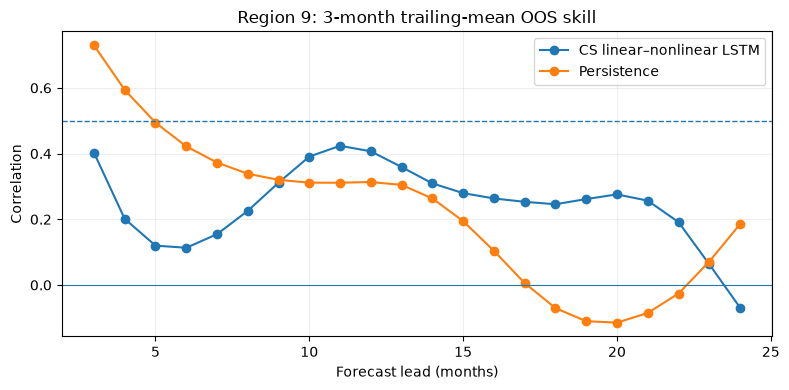

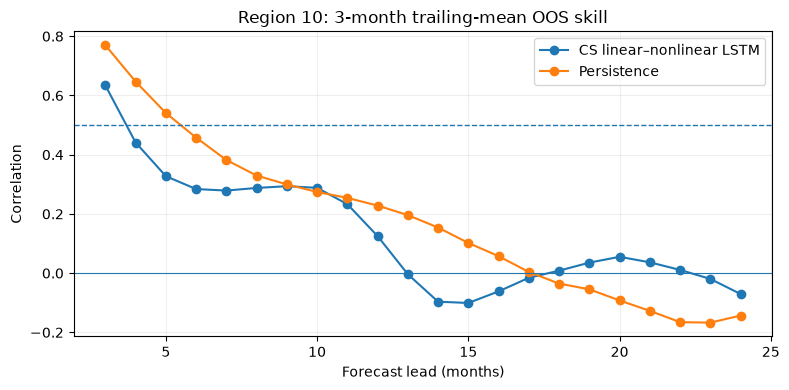

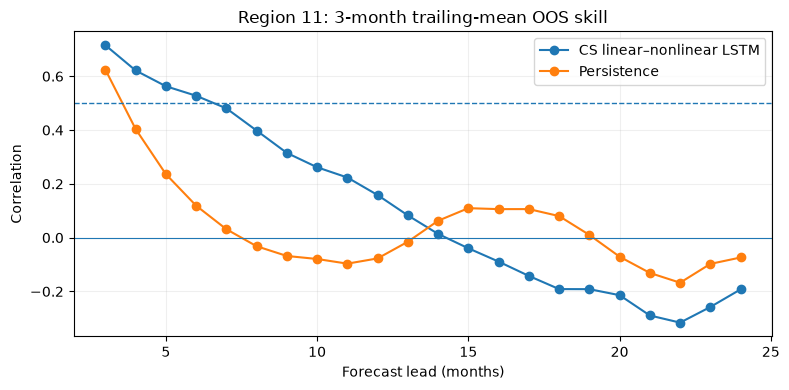

In [19]:
plot_skill_curves()

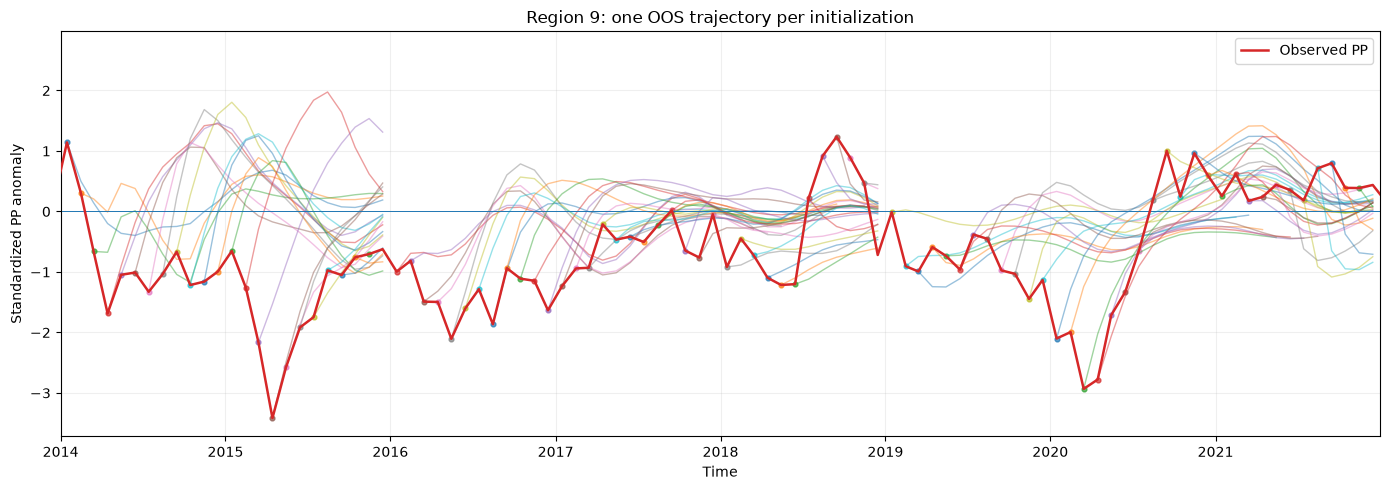

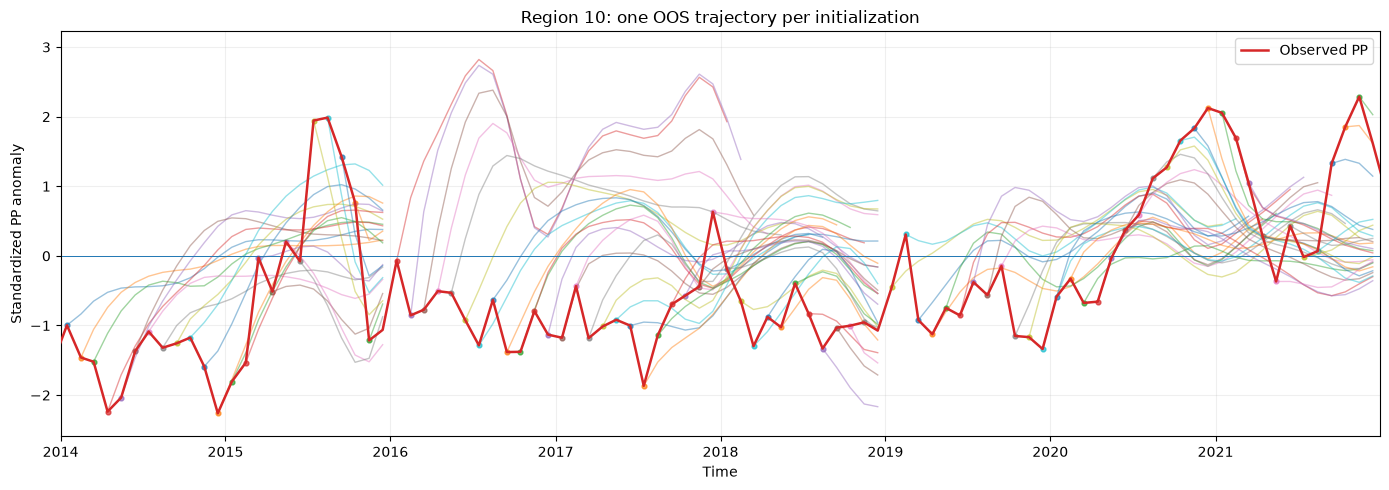

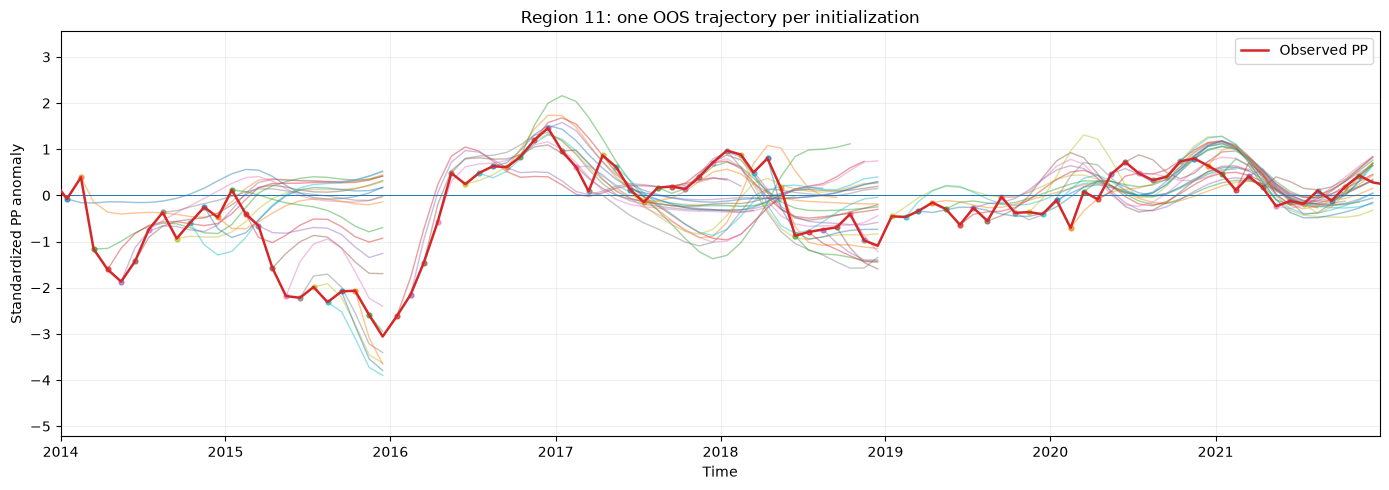

In [20]:
plot_spaghetti_region(9, every=1, start_date="2014-01-01", end_date="2021-12-31")
plot_spaghetti_region(10, every=1, start_date="2014-01-01", end_date="2021-12-31")
plot_spaghetti_region(11, every=1, start_date="2014-01-01", end_date="2021-12-31")